In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/loan_default.csv")

### 1 Data Overview

In [3]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
df.shape

(255347, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [6]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


### 2 Missing Values

In [7]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

### 3 Duplicate Rows

In [8]:
df.duplicated().sum()

np.int64(0)

### 4 Target Distribution

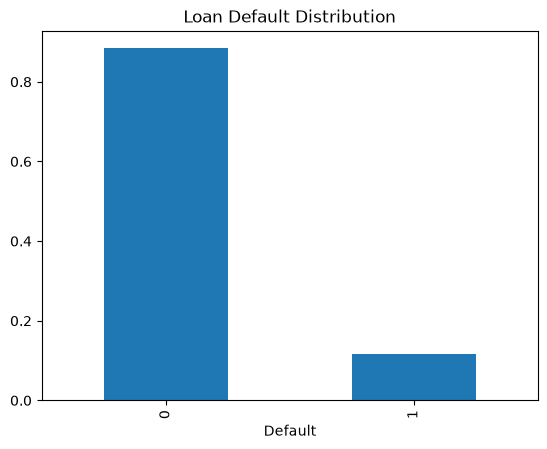

In [9]:
df["Default"].value_counts(normalize=True).plot(kind="bar")

plt.title("Loan Default Distribution")

plt.show()

### 5 Numerical Feature Distribution

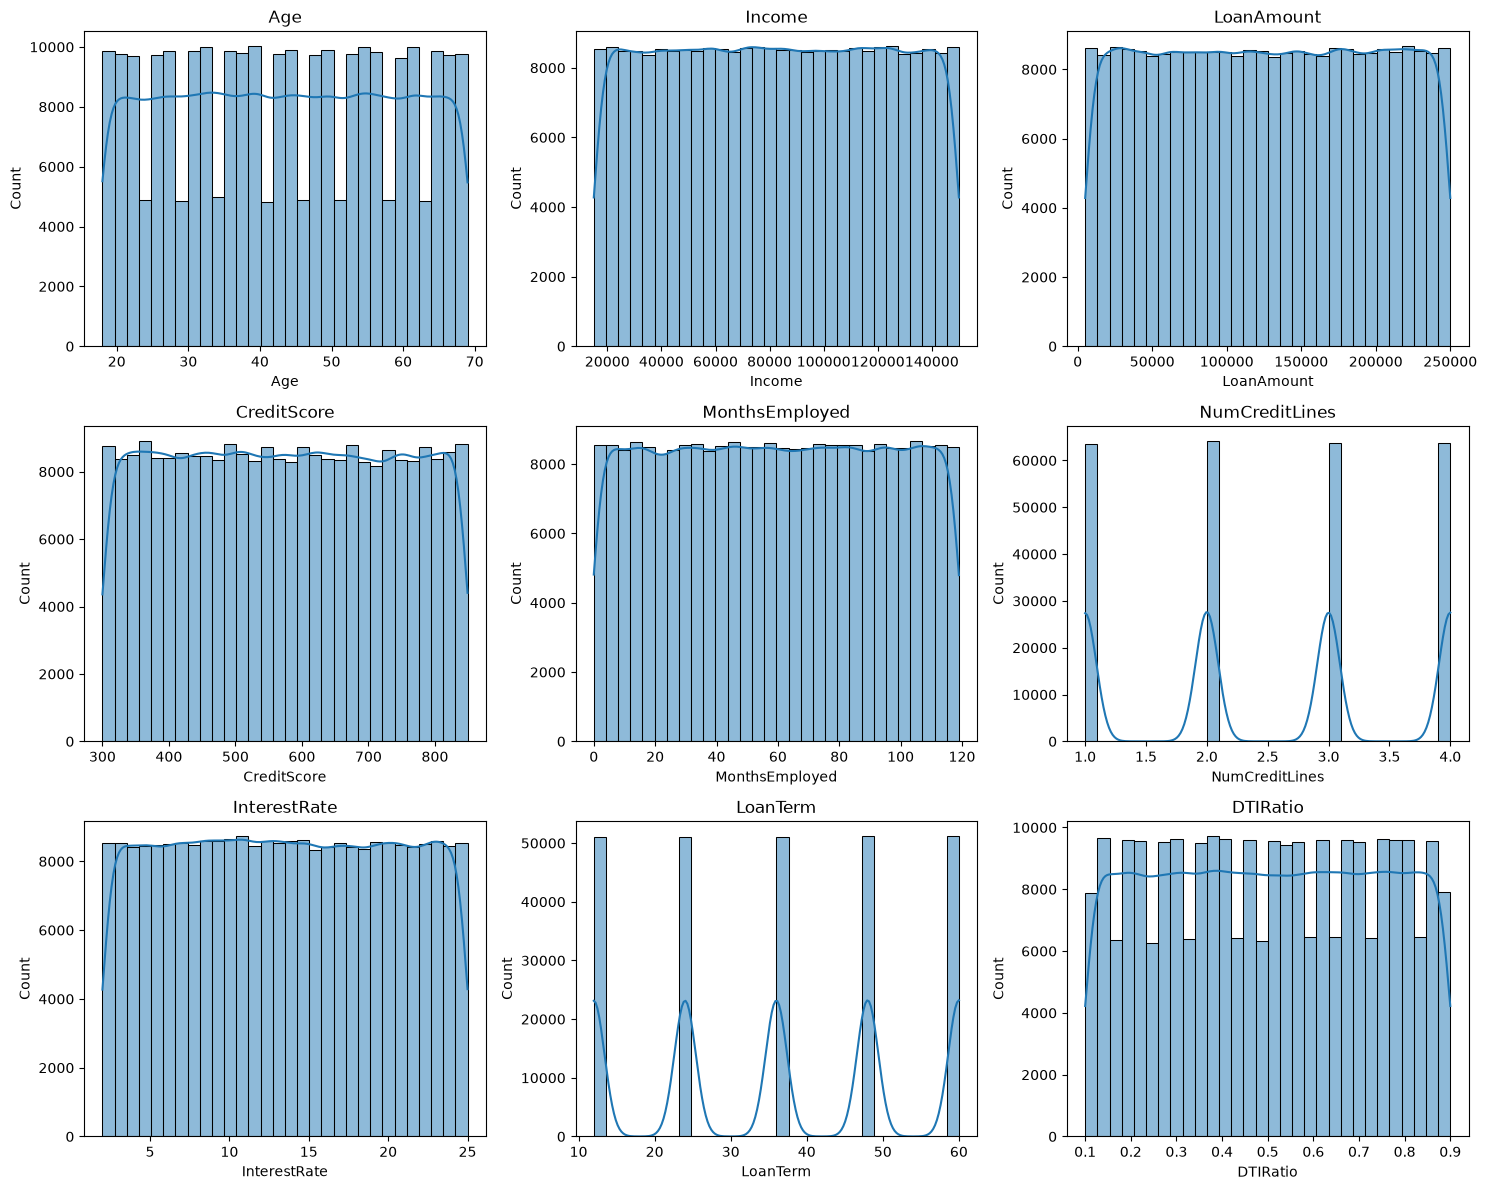

In [28]:
numerical_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
]
fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("../reports/figures/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 6 Boxplots

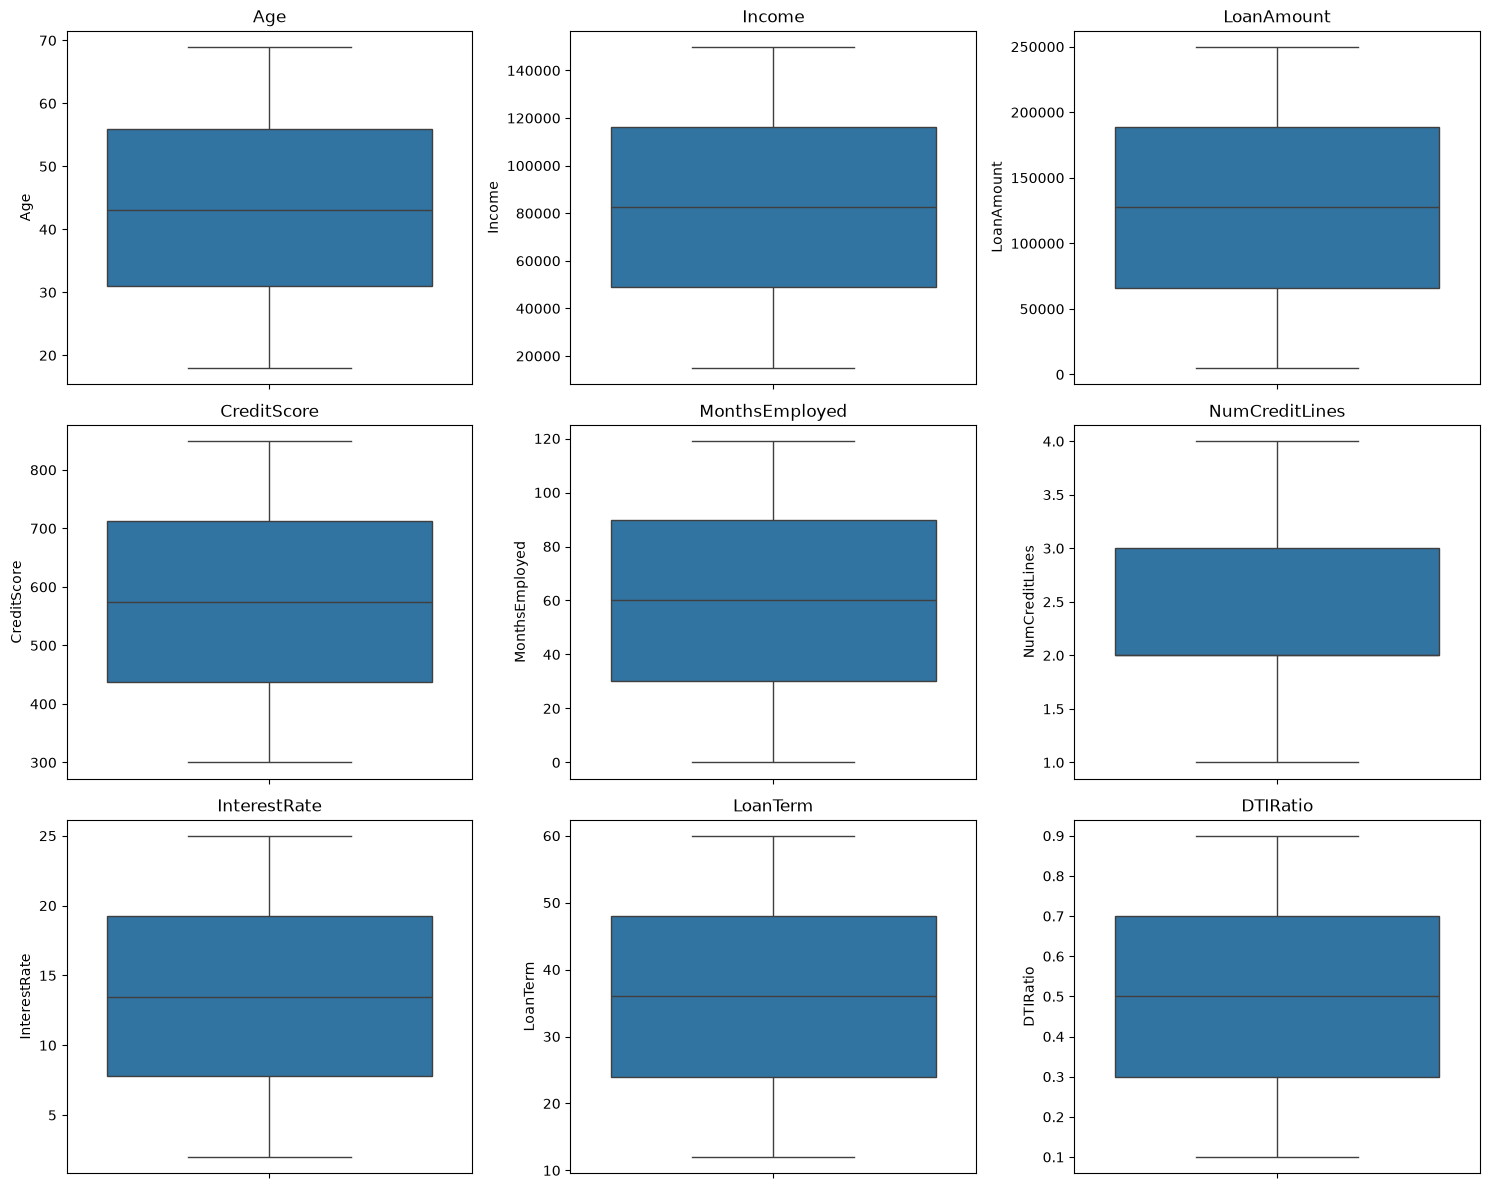

In [11]:
fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### 7 Categorical Feature Analysis

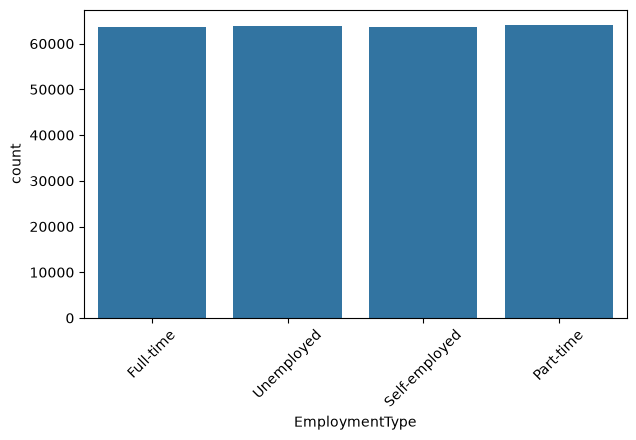

In [12]:
plt.figure(figsize=(7,4))

sns.countplot(data=df,x="EmploymentType")

plt.xticks(rotation=45)

plt.show()

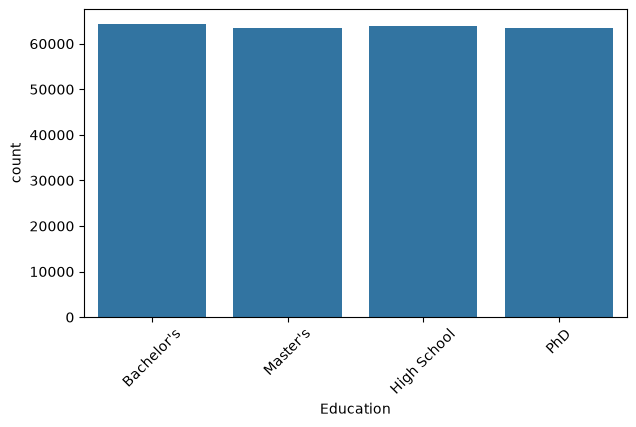

In [13]:
plt.figure(figsize=(7,4))

sns.countplot(data=df,x="Education")

plt.xticks(rotation=45)

plt.show()

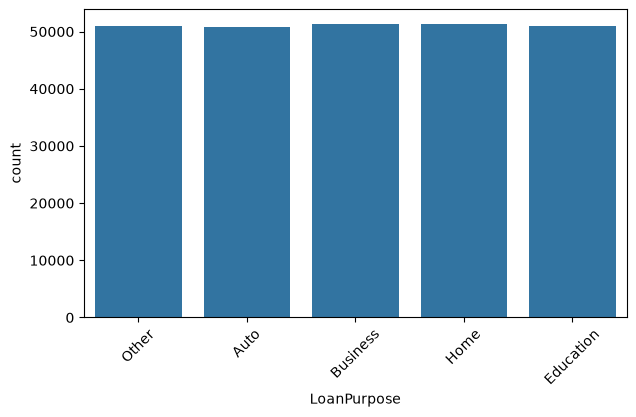

In [14]:
plt.figure(figsize=(7,4))

sns.countplot(data=df,x="LoanPurpose")

plt.xticks(rotation=45)

plt.show()

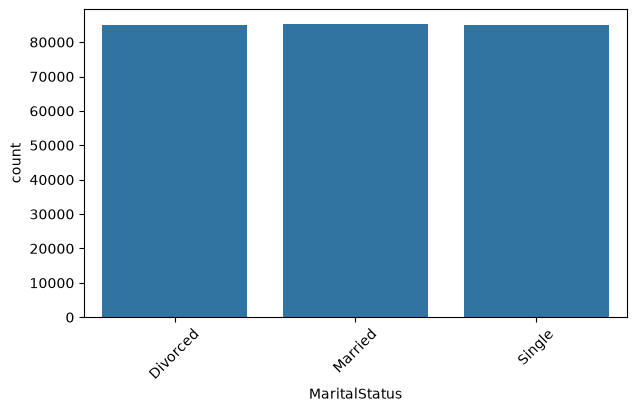

In [15]:
plt.figure(figsize=(7,4))

sns.countplot(data=df,x="MaritalStatus")

plt.xticks(rotation=45)

plt.show()

### 8 Correlation Heatmap

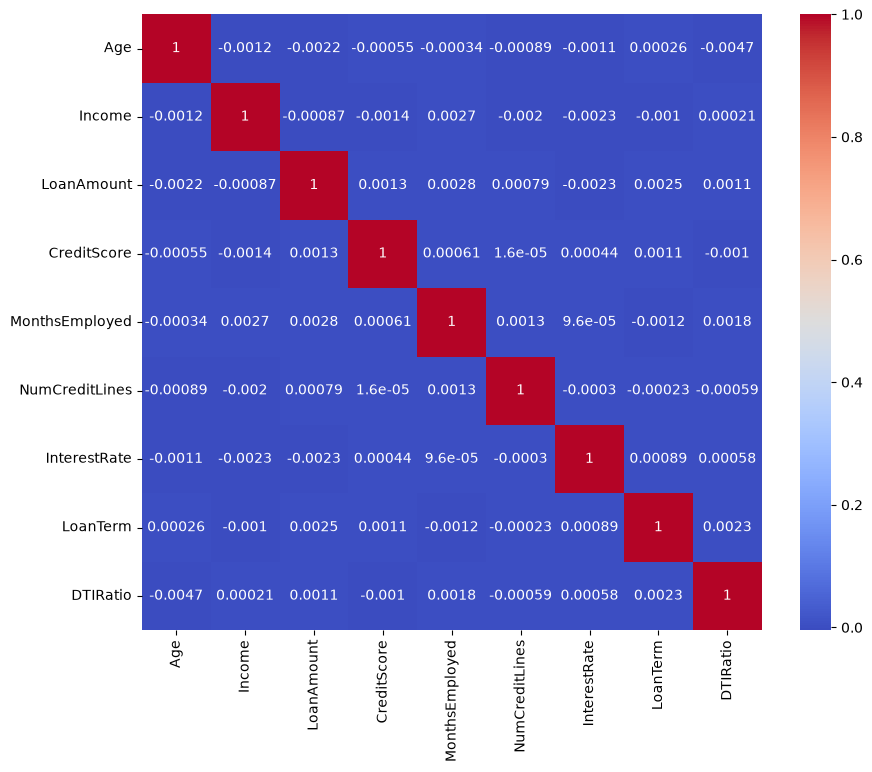

In [25]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")

### Insights


#### Insight 1: Default Rate by Income Bracket
Default rate is high for people with less income

<Axes: xlabel='Default', ylabel='Income'>

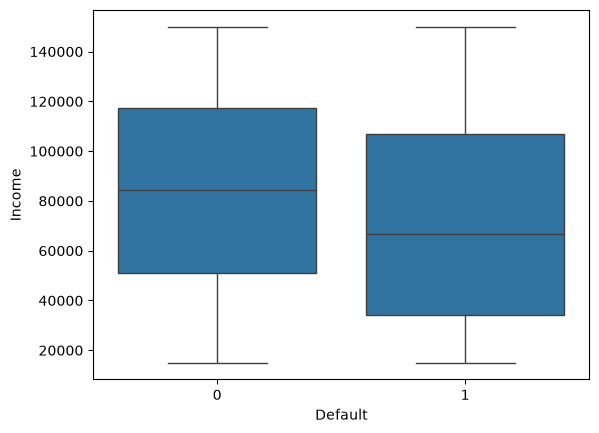

In [18]:
sns.boxplot(data=df, x="Default", y="Income")

#### Insight 2: Default Rate by Employment Type
Default rate is almost same for all employment type

<Axes: xlabel='EmploymentType'>

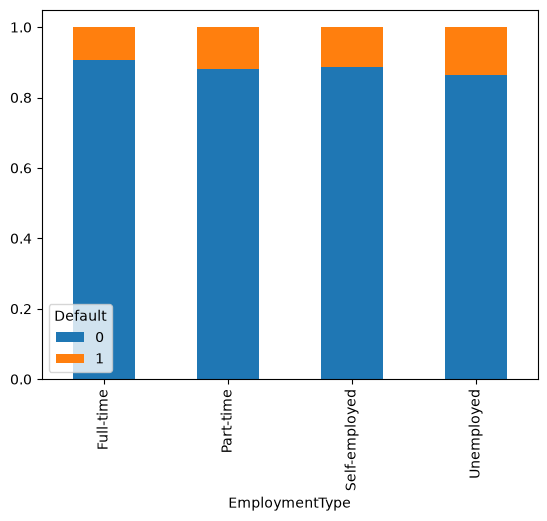

In [19]:
pd.crosstab(df["EmploymentType"], df["Default"],
normalize="index")\
.plot(kind="bar",
stacked=True)

#### Insight 3: Loan Amount vs Income
People with higher loan and less income tend to get in default

<Axes: xlabel='Income', ylabel='LoanAmount'>

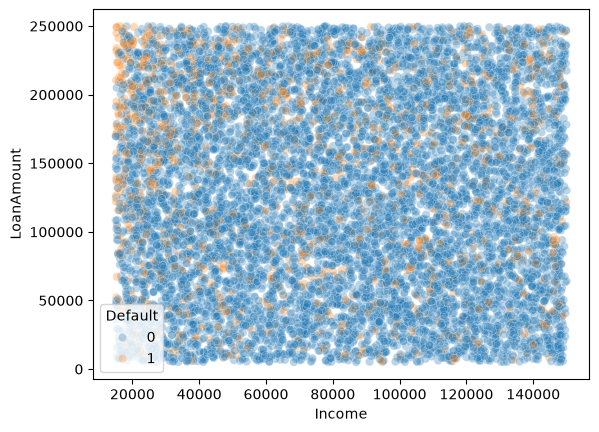

In [20]:
sample = df.sample(10000, random_state=42)
sns.scatterplot(data=sample, x="Income", y="LoanAmount", hue="Default", alpha=0.3)

#### Insight 4: Age vs Default
People in 25-45 age group tend to get default

<Axes: xlabel='Default', ylabel='Age'>

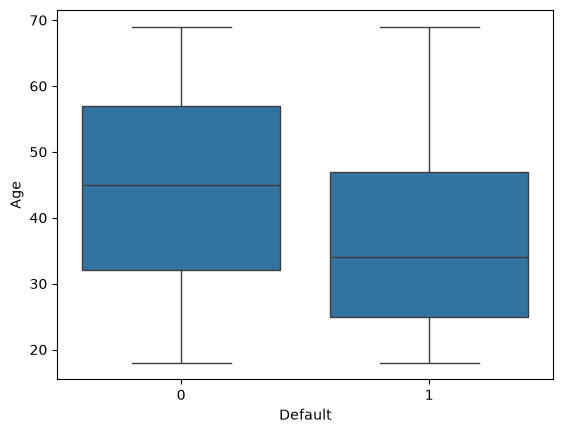

In [21]:
sns.boxplot(data=df, x="Default", y="Age")

#### Insight 5: Interest Rate vs Default
People with higher interest tend to get default

<Axes: xlabel='Default', ylabel='InterestRate'>

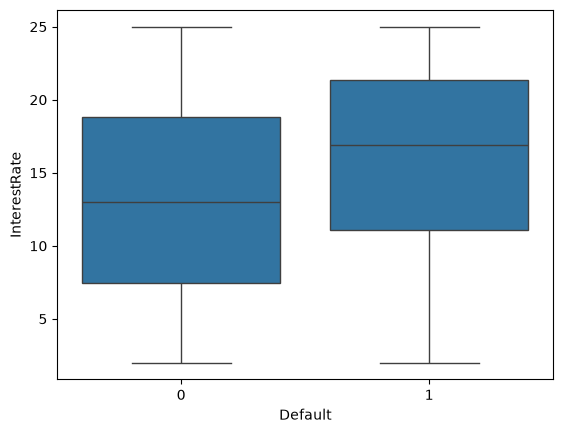

In [22]:
sns.boxplot(data=df, x="Default", y="InterestRate")

### Income Brackets

In [23]:
df["IncomeBracket"] = pd.qcut(df["Income"], q=5, labels=["Very Low","Low","Medium","High","Very High"])

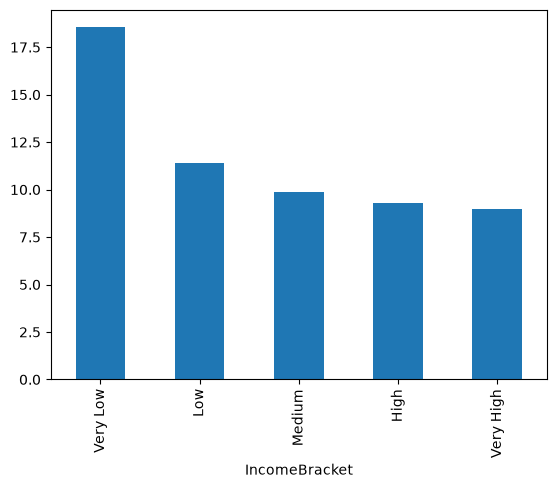

In [26]:
default_rate = df.groupby("IncomeBracket")["Default"].mean()*100
default_rate.plot(kind='bar')
plt.savefig("../reports/figures/numeric_distributions.png", dpi=150, bbox_inches="tight")